In [1]:
import cmdstanpy as csp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from cmdstanpy import install_cmdstan

install_cmdstan(dir="C:/cmdstan", overwrite=True, compiler=True)

18:33:17 - cmdstanpy - INFO - Add C++ toolchain to $PATH: C:\cmdstan\RTools40


CmdStan install directory: C:/cmdstan
Installing CmdStan version: 2.37.0
Download successful, file: C:\Users\sebas\AppData\Local\Temp\tmpx_ozqiiq
Extracting distribution
Unpacked download as cmdstan-2.37.0
Building version cmdstan-2.37.0, may take several minutes, depending on your system.
Overwrite requested, remove existing build of version cmdstan-2.37.0
Rebuilding version cmdstan-2.37.0
Installed cmdstan-2.37.0
Test model compilation


True

In [3]:
df = pd.read_csv("no2.csv")

### Model fitting

In [4]:
model = csp.CmdStanModel(stan_file="lognorm_fast.stan", force_compile=True)

18:44:00 - cmdstanpy - INFO - compiling stan file C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\lognorm_fast.stan to exe file C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\lognorm_fast.exe
18:44:34 - cmdstanpy - INFO - compiled model executable: C:\Users\sebas\one\OneDrive\Namizje\repos\BayesianStats\hw3\lognorm_fast.exe


In [5]:
df["day"] = df.index + 1

In [8]:
import numpy as np

# Log-transform your NO2 values (ensure y > 0)
df['log_y'] = np.log(df['no2'] + 0.001) 

data_dict = {
    "n": len(df),
    "t": df['day'].values,
    "log_y": df['log_y'].values, # Pass the logged values
    "k": 1,
    "omega": np.array([2 * np.pi / 7])
}

In [11]:
fit = model.sample(
    data=data_dict,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
)

19:18:28 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]



chain 1:   0%|          | 1/2000 [00:00<08:24,  3.96it/s, (Warmup)]






























Chain [1] Iteration: 1700 / 2000 [ 85%]  (Sampling)






chain 1:   5%|▌         | 100/2000 [01:58<37:39,  1.19s/it, (Warmup)]












chain 1:  10%|█         | 200/2000 [03:54<35:10,  1.17s/it, (Warmup)]

chain 1:  20%|██        | 400/2000 [05:02<16:22,  1.63it/s, (Warmup)]

Chain [1] Iteration: 1800 / 2000 [ 90%]  (Sampling)


...

Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 919.839 seconds (Warm-up)
Chain [1] 1731.42 seconds (Sampling)
Chain [1] 2651.26 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Ch

19:29:13 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] 





chain 1:  55%|█████▌    | 1100/2000 [13:42<13:18,  1.13it/s, (Sampling)]

chain 1:  60%|██████    | 1200/2000 [16:06<14:03,  1.05s/it, (Sampling)]

chain 1:  70%|███████   | 1400/2000 [20:40<12:07,  1.21s/it, (Sampling)]

chain 2: 100%|██████████| 2000/2000 [33:11<00:00,  1.00it/s, (Sampling completed)]

chain 3: 100%|██████████| 2000/2000 [33:11<00:00,  1.00it/s, (Sampling completed)]


chain 4: 100%|██████████| 2000/2000 [33:11<00:00,  1.00it/s, (Sampling completed)]


19:51:39 - cmdstanpy - INFO - CmdStan done processing.
19:51:39 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 921 iterations at max treedepth (92.1%)
	Chain 2 had 158 divergent transitions (15.8%)
	Chain 2 had 117 iterations at max treedepth (11.7%)
	Chain 3 had 276 iterations at max treedepth (27.6%)
	Chain 4 had 4 iterations at max treedepth (0.4%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_cos[0] -0.510  0.750  -1.701    0.130      0.372    0.171       5.0   
beta_sin[0]  0.249  0.367   0.024    0.887      0.183    0.105       5.0   
alpha        2.828  2.026   0.467    4.813      0.998    0.160       5.0   
beta         0.000  0.000  -0.000    0.001      0.000    0.000       5.0   
sigma        0.844  0.650   0.300    2.082      0.314    0.226       6.0   

             ess_tail  r_hat  
beta_cos[0]      11.0   2.58  
beta_sin[0]      11.0   2.23  
alpha            13.0   2.13  
beta             13.0   2.01  
sigma            11.0   2.27  


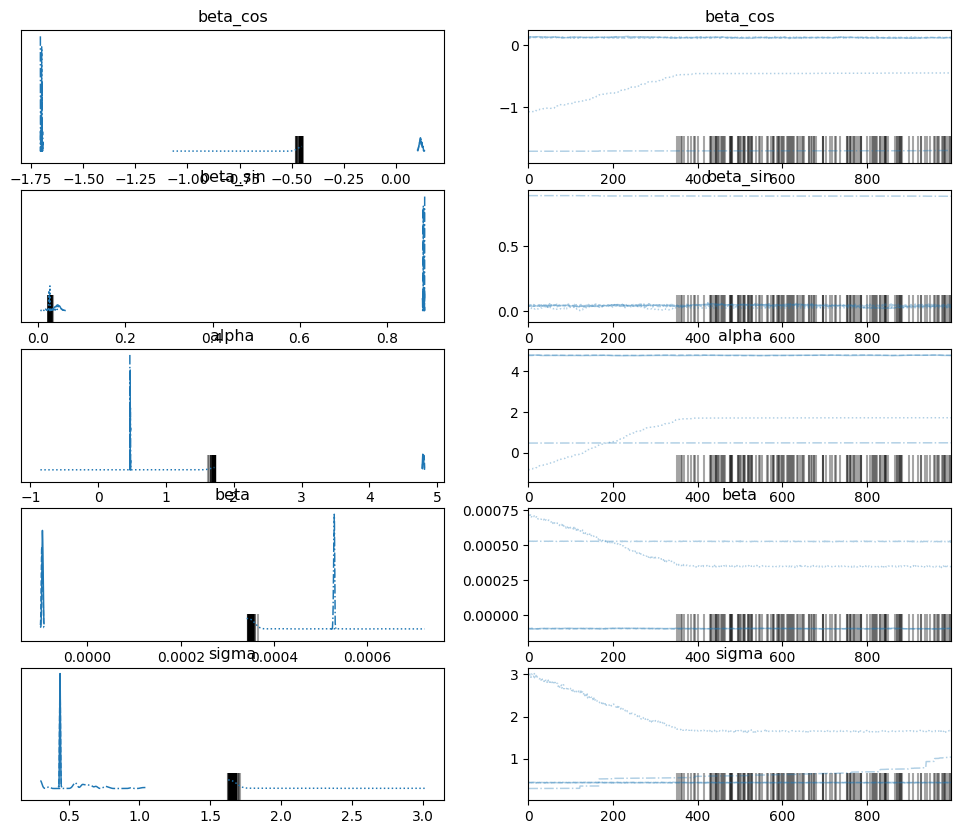

In [15]:
import arviz as az

# Convert fit to InferenceData
idata = az.from_cmdstanpy(fit)

# 1. Check Traceplots
# Look for "fuzzy caterpillars" - chains should overlap and not drift
az.plot_trace(idata)

# 2. Check Stats (R-hat and ESS)
summary = az.summary(idata)
print(summary)

In [13]:
draws = fit.stan_variables()

In [14]:
import numpy as np

# Extract the posterior means for all parameters
params = fit.stan_variables()
alpha_hat = params['alpha'].mean()
beta_hat = params['beta'].mean()
beta_cos_hat = params['beta_cos'].mean(axis=0) # Mean for each of the k components
beta_sin_hat = params['beta_sin'].mean(axis=0)

# We use the omega provided in the data dictionary
omega = stan_data['omega']
t_values = df['day'].values

# 1. Start with the linear trend: alpha + beta * t
trend = alpha_hat + beta_hat * t_values

# 2. Add the seasonality components
# Each component j is: beta_cos[j] * cos(omega[j] * t) + beta_sin[j] * sin(omega[j] * t)
seasonality = np.zeros(len(t_values))
seasonality += beta_cos_hat[j] * np.cos(omega[0] * t_values) + \
                beta_sin_hat[j] * np.sin(omega[0] * t_values)

# 3. Combine for the final prediction
df["pred"] = trend + seasonality

NameError: name 'stan_data' is not defined

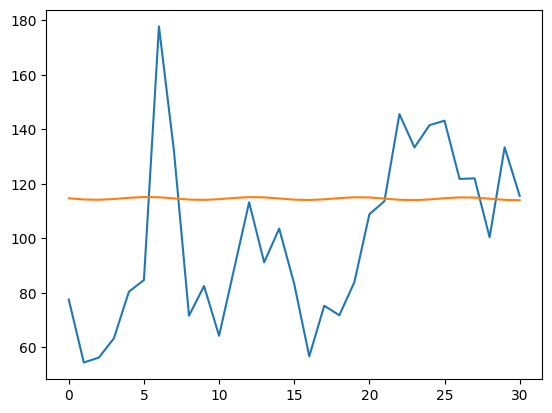

In [ ]:
plt.plot(df["no2"].iloc[:31])
plt.plot(df["pred"].iloc[:31])

In [ ]:
# Example for Weekly (J=3) and Yearly (J=10) seasonality
data_dict = {
    "n": len(df),
    "t": df['day'].values,
    "y": df['no2'].values,
    "num_seasonal": 2,
    "J": [3, 10],
    "periods": [7, 365.25]
}

In [ ]:
model_2 = csp.CmdStanModel("harmonic_2.stan")

21:14:59 - cmdstanpy - WARNING - CmdStanModel(model_name=...) is deprecated and will be removed in the next major version.


ValueError: Missing model file arguments, you must specify either Stan source or executable program file or both.